# Churn Prediction Model
building a random forest to predict which customers will churn and figuring out what drives it

In [12]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

load_dotenv('../.env')

conn = snowflake.connector.connect(
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
    database=os.getenv('SNOWFLAKE_DATABASE'),
    schema='CLEAN'
)

ibm_maven = pd.read_sql('SELECT * FROM IBM_MAVEN', conn)
ibm_maven['CHURN_BINARY'] = (ibm_maven['CHURN'] == 'Yes').astype(int)

print(f'loaded {len(ibm_maven)} rows')
print(f'churn rate: {ibm_maven["CHURN_BINARY"].mean()*100:.1f}%')

loaded 6589 rows
churn rate: 28.4%


## Preparing features
need to drop columns that would leak the answer or arent useful for prediction

In [13]:
# these columns cant be used as features:
# - CUSTOMERID: just an id, no predictive value
# - CHURN, CHURN_BINARY: thats what we're trying to predict 
# - CHURN_CATEGORY, CHURN_REASON: only known AFTER they leave, thats leakage
# - CITY, ZIP_CODE: too many unique values, would overfit
# - TOTAL_REVENUE, TOTAL_REFUNDS: calculated after the fact, also leakage

drop_cols = ['CUSTOMERID', 'CHURN', 'CHURN_CATEGORY', 'CHURN_REASON', 
             'CITY', 'ZIP_CODE', 'CHURN_BINARY', 'TOTAL_REVENUE', 'TOTAL_REFUNDS']

model_df = ibm_maven.copy()
model_df = model_df.drop(columns=drop_cols)

y = ibm_maven['CHURN_BINARY']

print(f'features: {model_df.shape[1]} columns')
print(f'target: {y.sum()} churned, {len(y) - y.sum()} stayed')

features: 26 columns
target: 1869 churned, 4720 stayed


In [14]:
# encoding categorical columns so the model can use them
# using LabelEncoder - not the best approach for production but works fine here
cat_cols = model_df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f'categorical columns to encode: {cat_cols}')

le_dict = {}  # saving encoders in case we need them later for the app
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = model_df[col].fillna('Unknown')
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    le_dict[col] = le

# fill remaining numeric nulls with median
model_df = model_df.fillna(model_df.median())

X = model_df
print(f'\nfinal feature matrix: {X.shape}')

categorical columns to encode: ['GENDER', 'MARRIED', 'DEPENDENTS', 'PHONESERVICE', 'MULTIPLELINES', 'INTERNETSERVICE', 'INTERNET_TYPE', 'ONLINESECURITY', 'ONLINEBACKUP', 'DEVICEPROTECTION', 'TECHSUPPORT', 'STREAMINGTV', 'STREAMINGMOVIES', 'STREAMING_MUSIC', 'UNLIMITED_DATA', 'CONTRACT', 'PAPERLESSBILLING', 'PAYMENTMETHOD', 'OFFER']

final feature matrix: (6589, 26)


## Training the model

In [15]:
# 80/20 split, stratified so both sets have same churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'train: {len(X_train)}, test: {len(X_test)}')
print(f'train churn rate: {y_train.mean()*100:.1f}%')
print(f'test churn rate: {y_test.mean()*100:.1f}%')

train: 5271, test: 1318
train churn rate: 28.4%
test churn rate: 28.4%


In [16]:
# random forest with max_depth=10 to avoid overfitting
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'ROC AUC: {roc_auc_score(y_test, y_proba):.3f}')

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       944
           1       0.82      0.60      0.69       374

    accuracy                           0.85      1318
   macro avg       0.84      0.77      0.80      1318
weighted avg       0.85      0.85      0.84      1318

ROC AUC: 0.909


In [17]:
# 85% accuracy and 0.909 AUC is pretty solid
# recall for churned customers (class 1) is 0.60 which means we catch 60% of churners
# not amazing but decent for a first pass
# TODO: could try tuning hyperparameters or using XGBoost to improve recall

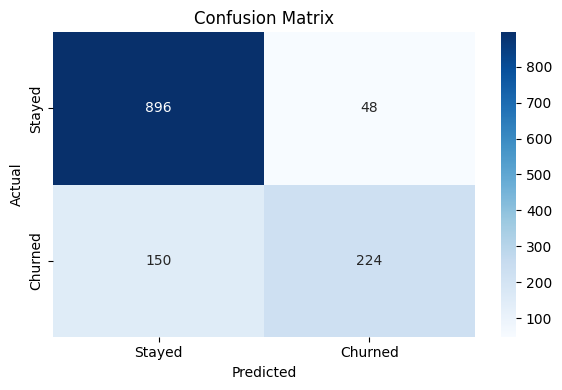

In [18]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('figures/07_confusion_matrix.png', dpi=150)
plt.show()

## Feature Importance
what features does the model think matter most?

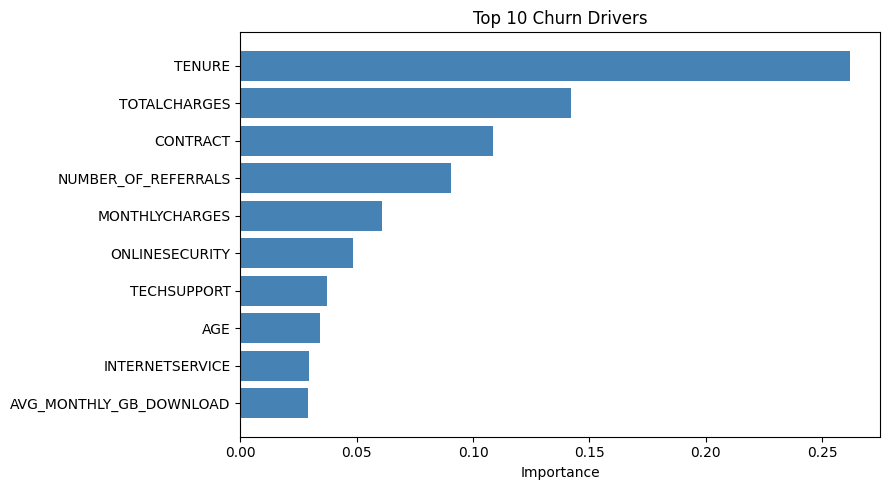

In [19]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

# just showing top 10
top10 = importances.tail(10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10['feature'], top10['importance'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Top 10 Churn Drivers')
plt.tight_layout()
plt.savefig('figures/08_feature_importance.png', dpi=150)
plt.show()

In [20]:
# tenure is the biggest driver by far - how long theyve been a customer
# then total charges, contract type, number of referrals, monthly charges
# online security and tech support also show up which is interesting
# 
# comparing this to the actual churn reasons from the data:
# - model says: tenure and contract type
# - customers say: 45% left for competitors
# both are true - short tenure month-to-month customers are the easiest 
# targets for competitors to poach

## Risk Segmentation
splitting customers into risk tiers based on their churn probability

In [21]:
# scoring every customer
ibm_maven['CHURN_PROBABILITY'] = rf.predict_proba(X)[:, 1]

ibm_maven['RISK_TIER'] = pd.cut(ibm_maven['CHURN_PROBABILITY'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'])

print(ibm_maven['RISK_TIER'].value_counts().sort_index())

RISK_TIER
Low Risk       4215
Medium Risk    1224
High Risk      1149
Name: count, dtype: int64


In [22]:
# summary stats for each risk tier
risk_summary = ibm_maven.groupby('RISK_TIER', observed=True).agg(
    count=('CHURN_PROBABILITY', 'count'),
    avg_churn_prob=('CHURN_PROBABILITY', 'mean'),
    actual_churn_rate=('CHURN_BINARY', 'mean'),
    avg_monthly_charges=('MONTHLYCHARGES', 'mean'),
    avg_tenure=('TENURE', 'mean')
).round(2)

print(risk_summary)

             count  avg_churn_prob  actual_churn_rate  avg_monthly_charges  \
RISK_TIER                                                                    
Low Risk      4215            0.08               0.03                59.96   
Medium Risk   1224            0.45               0.54                80.79   
High Risk     1149            0.85               0.95                73.76   

             avg_tenure  
RISK_TIER                
Low Risk          43.34  
Medium Risk       28.88  
High Risk          7.96  


In [23]:
# low risk: 4215 customers, only 2.6% actually churned, avg tenure 43 months
# medium risk: 1224 customers, 54% churned, avg tenure 29 months  
# high risk: 1149 customers, 95% churned, avg tenure 8 months
#
# the high risk group is almost all new customers (8 month avg tenure)
# paying decent money ($74/mo) and 95% of them left
# these are the ones the company needs to catch early

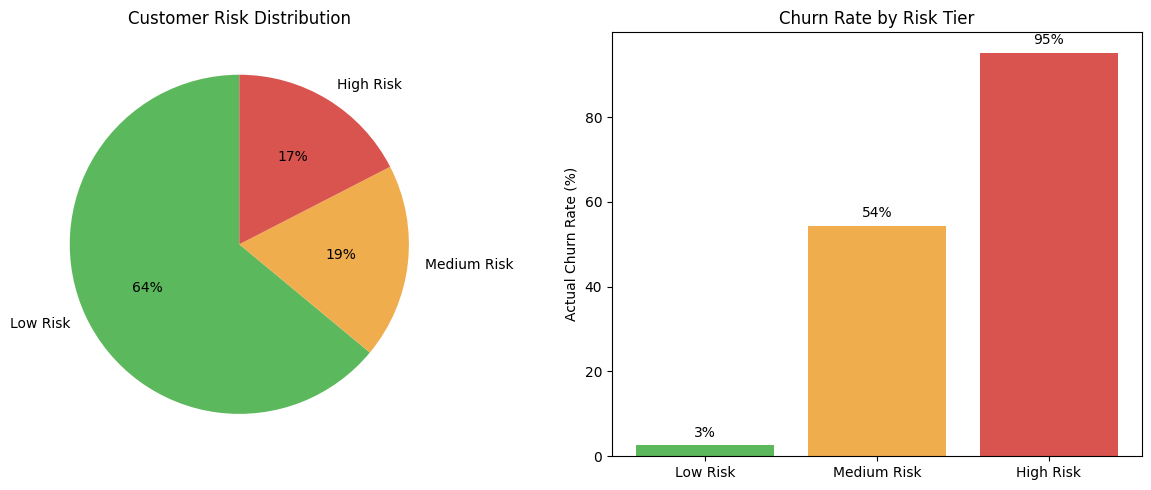

In [24]:
# visualizing the risk tiers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# pie chart
tier_counts = ibm_maven['RISK_TIER'].value_counts().sort_index()
colors_pie = ['#5cb85c', '#f0ad4e', '#d9534f']
axes[0].pie(tier_counts, labels=tier_counts.index, autopct='%1.0f%%',
            colors=colors_pie, startangle=90)
axes[0].set_title('Customer Risk Distribution')

# actual churn by tier
tier_churn = ibm_maven.groupby('RISK_TIER', observed=True)['CHURN_BINARY'].mean() * 100
axes[1].bar(tier_churn.index, tier_churn.values, color=colors_pie)
for i, val in enumerate(tier_churn.values):
    axes[1].text(i, val + 2, f'{val:.0f}%', ha='center')
axes[1].set_ylabel('Actual Churn Rate (%)')
axes[1].set_title('Churn Rate by Risk Tier')

plt.tight_layout()
plt.savefig('figures/09_risk_tiers.png', dpi=150)
plt.show()

In [25]:
# saving the scored data for the streamlit app later
ibm_maven.to_csv('../data/processed/scored_customers.csv', index=False)
print('saved scored customers to data/processed/')

saved scored customers to data/processed/


In [26]:
# saving the model too
import pickle

os.makedirs('../data/processed', exist_ok=True)

model_package = {
    'model': rf,
    'le_dict': le_dict,
    'feature_cols': list(X.columns)
}
with open('../data/processed/churn_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print('model saved')

model saved


---
## Summary

- Random Forest: 85% accuracy, 0.909 AUC
- Top drivers: tenure, total charges, contract type, referrals, monthly charges
- Risk tiers work well: high risk group has 95% actual churn rate
- Model predictions align with actual churn reasons - short tenure + month-to-month = easy target for competitors

Next: building the streamlit app with the risk predictor

In [27]:
kaggle.to_csv('../data/processed/kaggle_telecoms.csv', index=False)